Recognized Equation: 2y-8


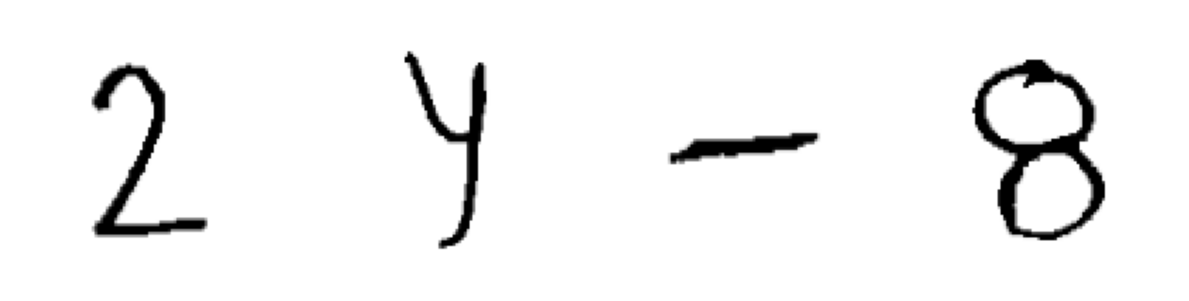

In [16]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# from tensorflow.keras.models import load_model

# # Load the trained model
# model = load_model("math_symbol_classifier2.h5")

# # Define label-to-character mapping
# label_map = {
#     0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 
#     5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 
#     10: '+', 11: '*', 12: '-', 13: 'y', 14: 'z'
# }

# # Preprocess function
# def preprocess_image(frame):
#     resized_img = cv2.resize(frame, (100, 100))
#     resized_img = resized_img / 255.0  # Normalize to [0,1]
#     final_img = np.expand_dims(resized_img, axis=0)  # Shape: (1, 100, 100, 3)
#     return final_img

# # STEP 1: Load and preprocess the image
# image_path = "OCR_API/img4.jpg"
# frame = cv2.imread(image_path)

# # Convert to grayscale
# gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# # Apply binary thresholding (invert to get white chars on black)
# _, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV)

# # Find contours
# contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# # Sort contours from left to right
# bounding_boxes = [cv2.boundingRect(c) for c in contours]
# bounding_boxes = sorted(bounding_boxes, key=lambda x: x[0])  # sort by x

# # Output string
# recognized_equation = ""
# segmented_images = []

# # STEP 2: Segment and classify each character with padding
# for (x, y, w, h) in bounding_boxes:
#     # Add padding
#     pad = 20
#     x_start = max(x - pad, 0)
#     y_start = max(y - pad, 0)
#     x_end = min(x + w + pad, binary.shape[1])
#     y_end = min(y + h + pad, binary.shape[0])

#     # Extract character
#     char_img = binary[y_start:y_end, x_start:x_end]

#     # Invert again (black on white)
#     char_img = cv2.bitwise_not(char_img)

#     # Convert to 3-channel
#     char_img = cv2.cvtColor(char_img, cv2.COLOR_GRAY2RGB)

#     # Make square by padding the shorter side
#     h_crop, w_crop = char_img.shape[:2]
#     if h_crop != w_crop:
#         size = max(h_crop, w_crop)
#         square_img = np.ones((size, size, 3), dtype=np.uint8) * 255
#         y_offset = (size - h_crop) // 2
#         x_offset = (size - w_crop) // 2
#         square_img[y_offset:y_offset+h_crop, x_offset:x_offset+w_crop] = char_img
#         char_img = square_img

#     # Resize
#     char_img = cv2.resize(char_img, (100, 100))

#     # Store for visualization
#     segmented_images.append(char_img)

#     # Predict
#     img = preprocess_image(char_img)
#     predictions = model.predict(img)
#     predicted_label = np.argmax(predictions)
#     predicted_symbol = label_map.get(predicted_label, "Unknown")
#     recognized_equation += predicted_symbol

# # STEP 3: Print result
# print(f"Recognized Equation: {recognized_equation}")

# # STEP 4: Visualize characters
# fig, axes = plt.subplots(1, len(segmented_images), figsize=(10, 3))
# for ax, img in zip(axes, segmented_images):
#     ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#     ax.axis('off')
# plt.show()



import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("math_symbol_classifier2.h5")

# Label map
label_map = {
    0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 
    5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 
    10: '+', 11: '*', 12: '-', 13: 'y', 14: 'z'
}

# Preprocessing for prediction
def preprocess_image(frame):
    resized_img = cv2.resize(frame, (100, 100))
    resized_img = resized_img / 255.0
    final_img = np.expand_dims(resized_img, axis=0)
    return final_img

# Adaptive square padding function
def prepare_char_image(img, target_size=100, margin=20):
    h, w = img.shape
    size = max(h, w) + 2 * margin
    square = np.ones((size, size), dtype=np.uint8) * 255
    y_offset = (size - h) // 2
    x_offset = (size - w) // 2
    square[y_offset:y_offset+h, x_offset:x_offset+w] = img
    resized = cv2.resize(square, (target_size, target_size))
    colored = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)
    return colored

# Load and preprocess image
#image_path = "OCR_API/valid_ocr_images/handwritten_img7.jpg"
image_path = "Test_images_incorrect/eqn6.jpg"
#image_path = "Test_images_correct/eqn5.png"
frame = cv2.imread(image_path)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY_INV)                  # initial original value 128 and new value 150

# Use connected components for robust segmentation
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
min_area = 100  # You can tweak this based on image scale
filtered_stats = [tuple(stat[:4]) for stat in stats[1:] if stat[4] > min_area]  # Exclude background

# Sort by x (left to right)
bounding_boxes = sorted(filtered_stats, key=lambda b: b[0])

recognized_equation = ""
segmented_images = []

# Process each box
for (x, y, w, h) in bounding_boxes:
    roi = binary[y:y+h, x:x+w]
    roi = cv2.bitwise_not(roi)  # black text on white background

    processed_char = prepare_char_image(roi)
    segmented_images.append(processed_char)

    img = preprocess_image(processed_char)
    predictions = model.predict(img, verbose=0)
    predicted_label = np.argmax(predictions)
    predicted_symbol = label_map.get(predicted_label, "Unknown")
    recognized_equation += predicted_symbol

# Output
print(f"Recognized Equation: {recognized_equation}")

# Visualize segmented characters
fig, axes = plt.subplots(1, len(segmented_images), figsize=(12, 4))
for ax, img in zip(axes, segmented_images):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout()
plt.show()


In [10]:
import re

def fix_multiplication_symbols(extracted_text):
    """
    - Replaces standalone 'X' or 'x' with '*'
    - Converts '7X4' → '7*4' (Arithmetic multiplication)
    - Converts '4X' → '4*X' (Variable handling)
    """
    # Case 1: Replace 'X' or 'x' used as a multiplication sign between numbers
    fixed_text = re.sub(r'(\d)\s*[Xx]\s*(\d)', r'\1*\2', extracted_text)

    # Case 2: Replace standalone 'X' or 'x' (used for multiplication)
    fixed_text = re.sub(r'\b[Xx]\b', '*', fixed_text)

    # Case 3: Insert '*' between a number and any variable (a-z, A-Z)
    fixed_text = re.sub(r'(\d)([A-Za-z])', r'\1*\2', fixed_text)

    return fixed_text

In [12]:
corrected_equation = fix_multiplication_symbols(recognized_equation)
print("Corrected Equation:", corrected_equation)

Corrected Equation: 2*y-8


In [13]:
from sympy import sympify, solve, symbols

def process_equation(corrected_text):
    try:
        # Check if the equation contains a variable (A-Z, a-z)
        if any(char.isalpha() for char in corrected_text):
            # Extract the variable (assumes only one variable)
            variable_chars = [char for char in corrected_text if char.isalpha()]
            variable = symbols(variable_chars[0])  # Use the first detected variable

            # Convert to a sympy equation and solve (assume = 0)
            equation = sympify(corrected_text)  # Convert text to symbolic equation
            solution = solve(equation, variable)  # Solve for the variable

            return f"{variable} = {solution}"
        else:
            # No variable found → Directly evaluate the arithmetic expression
            return f"Result: {sympify(corrected_text)}"

    except Exception as e:
        return f"Error: {e}"


In [14]:
def handle_corrected_equation(corrected_equation):
    """
    Passes the corrected equation to process_equation() and returns the result.
    """
    result = process_equation(corrected_equation)
    return result



# Call the function
final_output = handle_corrected_equation(corrected_equation)

# Print the result
print("Final Output:", final_output)


Final Output: y = [4]
